In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

In [1]:
import sys

sys.path.append("../bayesian_trees")

In [3]:
import logging

import numpy as np
import pandas as pd

from bayesian_trees.adabooster import AdaBooster
from bayesian_trees.bayesian_tree import BayesianTree
from bayesian_trees.gradient_booster import GradientBooster
from bayesian_trees.random_forest import RandomForest
from bayesian_trees.sigmoid_calibrator import SigmoidCalibrator
from bayesian_trees.tree_utils import get_log_loss, plot_performance_chart

pd.DataFrame.iteritems = pd.DataFrame.items

logger = logging.getLogger(__name__)
logging_formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")
logging_file_handler = logging.FileHandler(filename="adult_census_income.log")
logging_console_handler = logging.StreamHandler()
logging_file_handler.setFormatter(logging_formatter)
logging_console_handler.setFormatter(logging_formatter)
logging.basicConfig(handlers=[logging_console_handler, logging_file_handler], level=logging.INFO)

In [4]:
LEARN_DATA_FILE = "../datasets/adult_census_income/adult.data"
TEST_DATA_FILE = "../datasets/adult_census_income/adult.test"

RAW_DATA_COLS = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income"
]
RAW_DATA_NUMERIC_COLS = [
    "age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"
]

OUTCOMES_COLS = ["negative", "positive"]

In [5]:
raw_learn_data = pd.read_csv(
    LEARN_DATA_FILE,
    sep=", ",
    header=None,
    na_values=["?"],
    names=RAW_DATA_COLS,
    engine="python"
)
raw_learn_data["negative"] = np.where(raw_learn_data["income"] == "<=50K", 1, 0)
raw_learn_data["positive"] = np.where(raw_learn_data["income"] == ">50K", 1, 0)
raw_learn_data.drop(columns=(["income"] + RAW_DATA_NUMERIC_COLS), inplace=True)
logger.info(f"Raw Learning Set Shape: {raw_learn_data.shape}")

raw_test_data = pd.read_csv(
    TEST_DATA_FILE,
    sep=", ",
    header=None,
    skiprows=1,
    na_values=["?"],
    names=RAW_DATA_COLS,
    engine="python"
)
raw_test_data["negative"] = np.where(raw_test_data["income"] == "<=50K.", 1, 0)
raw_test_data["positive"] = np.where(raw_test_data["income"] == ">50K.", 1, 0)
raw_test_data.drop(columns=(["income"] + RAW_DATA_NUMERIC_COLS), inplace=True)
logger.info(f"Raw Testing Set Shape: {raw_test_data.shape}")

logger.info("Raw Learning Set Stats:")
for c in raw_learn_data.columns:
    logger.info(
        f"{c}: {raw_learn_data[c].dtype} {len(raw_learn_data[c].unique())}"
        f" {raw_learn_data[c].isnull().sum()}"
    )

PREDICTORS = [c for c in raw_learn_data.columns if c not in OUTCOMES_COLS]

2026-03-04 15:15:42,555 - __main__ - INFO - Raw Learning Set Shape: (32561, 10)
2026-03-04 15:15:42,722 - __main__ - INFO - Raw Testing Set Shape: (16281, 10)
2026-03-04 15:15:42,723 - __main__ - INFO - Raw Learning Set Stats:
2026-03-04 15:15:42,737 - __main__ - INFO - workclass: str 9 1836
2026-03-04 15:15:42,743 - __main__ - INFO - education: str 16 0
2026-03-04 15:15:42,747 - __main__ - INFO - marital-status: str 7 0
2026-03-04 15:15:42,751 - __main__ - INFO - occupation: str 15 1843
2026-03-04 15:15:42,756 - __main__ - INFO - relationship: str 6 0
2026-03-04 15:15:42,761 - __main__ - INFO - race: str 5 0
2026-03-04 15:15:42,766 - __main__ - INFO - sex: str 2 0
2026-03-04 15:15:42,769 - __main__ - INFO - native-country: str 42 583
2026-03-04 15:15:42,770 - __main__ - INFO - negative: int64 2 0
2026-03-04 15:15:42,771 - __main__ - INFO - positive: int64 2 0


In [6]:
learn_data = raw_learn_data
test_data = raw_test_data

2026-03-04 15:16:54,939 - __main__ - INFO - DONE.
2026-03-04 15:16:56,019 - __main__ - INFO - Log-Loss: 0.3674
/tmp/ipykernel_115357/488170052.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


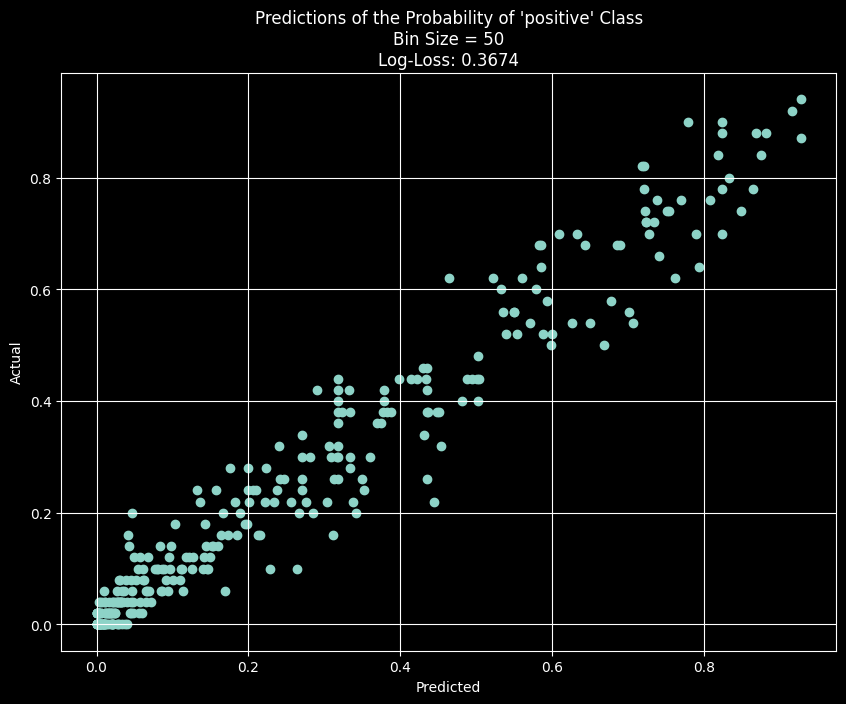

In [7]:
model_kwargs = {
    "split_method": "gain",
    "prior_method": "mle",
    "prior_alpha": [1.0, 1.0],
    "prior_cap": 100,
    "min_smooth_obs": 100,
    "min_prediction": 1e-6,
    "min_improvement": 1e-6,
    "write_log": False
}
model = BayesianTree(**model_kwargs)
model.fit(X=learn_data[PREDICTORS], y=learn_data[OUTCOMES_COLS])
logger.info("DONE.")

predictions = model.predict_proba(test_data[PREDICTORS])
loss = get_log_loss(predictions, test_data[OUTCOMES_COLS])
logger.info(f"Log-Loss: {loss:.4f}")

f, plot_data = plot_performance_chart(
    predictions, test_data[OUTCOMES_COLS], "positive", 50, loss
)
f.show()

2026-03-04 15:17:25,125 - __main__ - INFO - DONE.
2026-03-04 15:17:26,262 - __main__ - INFO - Log-Loss: 0.3674
/tmp/ipykernel_115357/3058602324.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


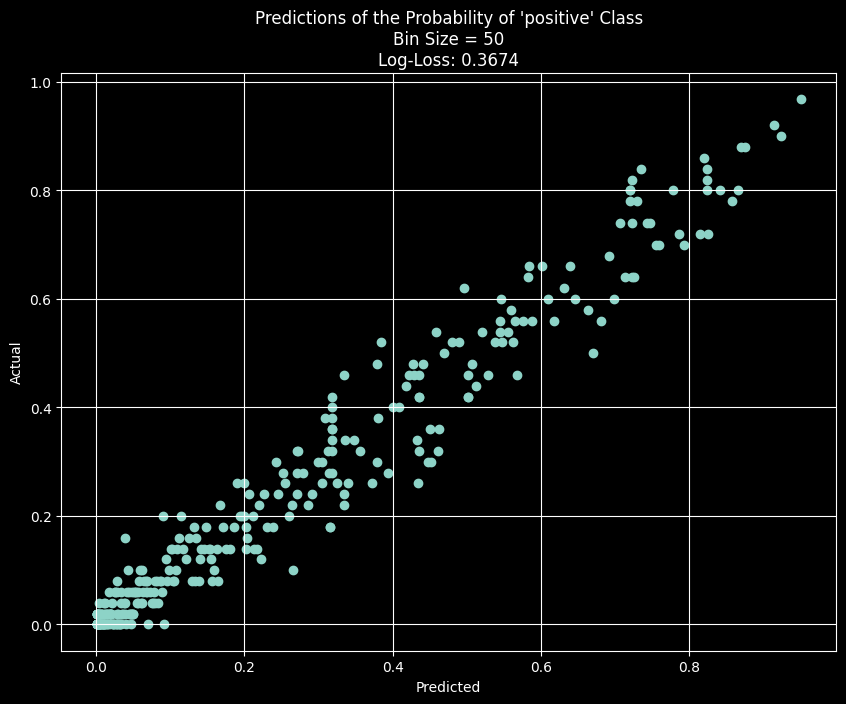

In [8]:
model_kwargs = {
    "split_method": "gain",
    "prior_method": "counting",
    "prior_alpha": [1.0, 1.0],
    "prior_cap": 100,
    "min_smooth_obs": None,
    "min_prediction": 1e-6,
    "min_improvement": 1e-6,
    "write_log": False
}
model = BayesianTree(**model_kwargs)
model.fit(X=learn_data[PREDICTORS], y=learn_data[OUTCOMES_COLS])
logger.info("DONE.")

predictions = model.predict_proba(test_data[PREDICTORS])
loss = get_log_loss(predictions, test_data[OUTCOMES_COLS])
logger.info(f"Log-Loss: {loss:.4f}")

f, plot_data = plot_performance_chart(
    predictions, test_data[OUTCOMES_COLS], "positive", 50, loss
)
f.show()

2026-03-04 15:17:51,053 - bayesian_trees.random_forest - INFO - Building tree #0...
2026-03-04 15:17:57,527 - bayesian_trees.random_forest - INFO - Training Log-Loss: 0.3702
2026-03-04 15:17:57,528 - bayesian_trees.random_forest - INFO - Building tree #1...
2026-03-04 15:18:05,453 - bayesian_trees.random_forest - INFO - Training Log-Loss: 0.3684
2026-03-04 15:18:05,454 - bayesian_trees.random_forest - INFO - Building tree #2...
2026-03-04 15:18:15,291 - bayesian_trees.random_forest - INFO - Training Log-Loss: 0.3626
2026-03-04 15:18:15,292 - bayesian_trees.random_forest - INFO - Building tree #3...
2026-03-04 15:18:22,496 - bayesian_trees.random_forest - INFO - Training Log-Loss: 0.3739
2026-03-04 15:18:22,497 - bayesian_trees.random_forest - INFO - Building tree #4...
2026-03-04 15:18:33,601 - bayesian_trees.random_forest - INFO - Training Log-Loss: 0.3582
2026-03-04 15:18:33,602 - bayesian_trees.random_forest - INFO - Building tree #5...
2026-03-04 15:18:40,447 - bayesian_trees.rando

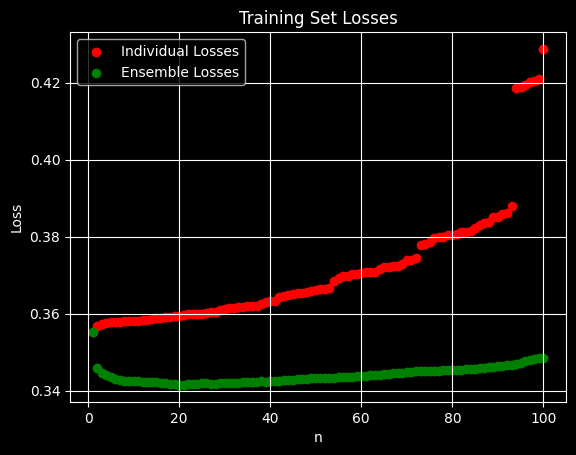

2026-03-04 15:34:35,073 - bayesian_trees.random_forest - INFO - Losses:
      n  individual_losses  ensemble_losses
0     1           0.387512         0.387512
1     2           0.385668         0.375595
2     3           0.381001         0.372642
3     4           0.383881         0.372204
4     5           0.382231         0.370405
5     6           0.387079         0.370395
6     7           0.392285         0.370925
7     8           0.384294         0.370274
8     9           0.380503         0.369461
9    10           0.382280         0.368864
10   11           0.386063         0.368857
11   12           0.384139         0.368623
12   13           0.386741         0.368800
13   14           0.392278         0.368767
14   15           0.389742         0.368872
15   16           0.387434         0.368493
16   17           0.384922         0.368388
17   18           0.390005         0.368179
18   19           0.391135         0.368327
19   20           0.391177         0.368309
20  

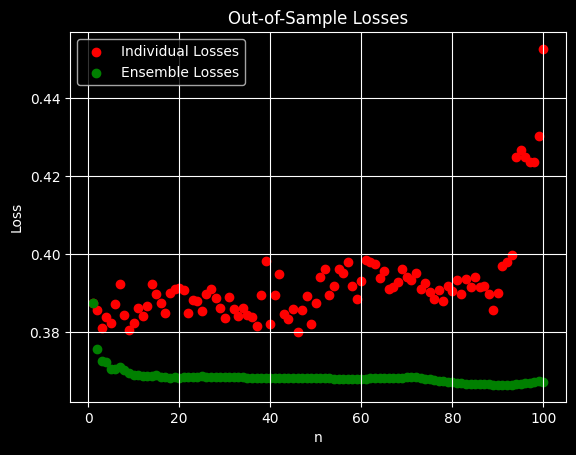

2026-03-04 15:34:35,240 - __main__ - INFO - Optimized number of trees: 92
2026-03-04 15:36:38,276 - bayesian_trees.random_forest - INFO - Losses:
      n  individual_losses  ensemble_losses
0     1           0.380283         0.380283
1     2           0.385813         0.370891
2     3           0.380875         0.369220
3     4           0.377945         0.367817
4     5           0.380223         0.366649
5     6           0.381820         0.366443
6     7           0.380677         0.366008
7     8           0.378851         0.365268
8     9           0.378545         0.364895
9    10           0.375700         0.364574
10   11           0.382282         0.364413
11   12           0.379339         0.364256
12   13           0.377886         0.364168
13   14           0.384007         0.364065
14   15           0.380146         0.363952
15   16           0.383501         0.363622
16   17           0.383483         0.363584
17   18           0.386712         0.363569
18   19           

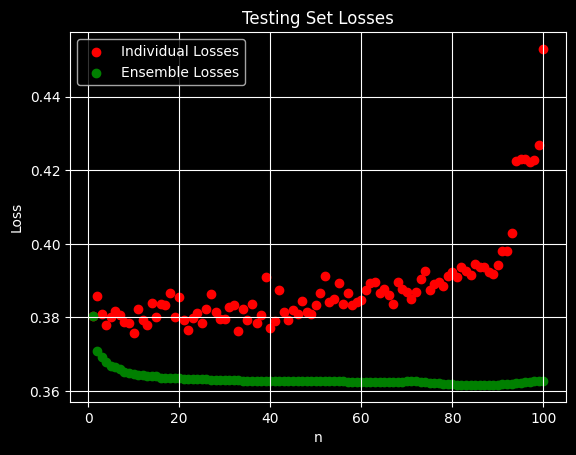

2026-03-04 15:38:22,491 - __main__ - INFO - Log-Loss: 0.3618
/tmp/ipykernel_115357/786016502.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


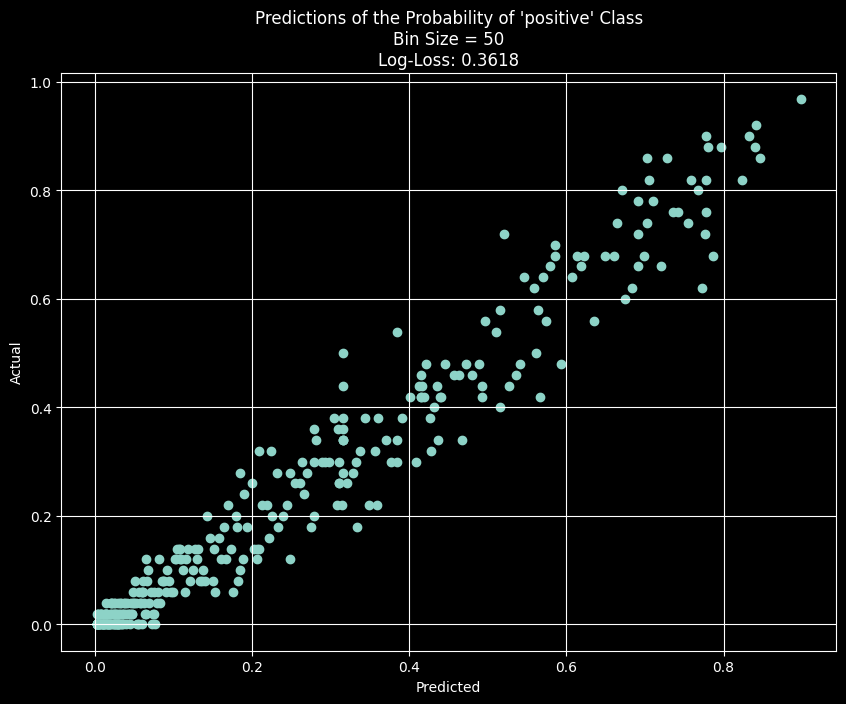

In [9]:
n_trees = 100
oos_frac = 0.2

tree_kwargs = {
    "split_method": "gain",
    "prior_method": "mle",
    "prior_alpha": [1.0, 1.0],
    "prior_cap": 100,
    "min_smooth_obs": 100,
    "min_prediction": 1e-6,
    "min_improvement": 1e-6,
    "max_level": None,
    "predictors_to_ignore": 0.3,
    "write_log": False
}
forest_kwargs = {
    "n_trees": n_trees,
    "predictors_to_remove": 0.3,
    "sampling_frac": 0.7,
    "random_state": 1234,
}

train_ind = np.random.choice(
    learn_data.shape[0],
    round((1.0 - oos_frac) * learn_data.shape[0]),
    replace=False
)

train_data = learn_data.loc[train_ind, :]
train_data.reset_index(drop=True, inplace=True)
oos_data = learn_data.loc[~learn_data.index.isin(train_ind), :]
oos_data.reset_index(drop=True, inplace=True)

random_forest = RandomForest(**{**forest_kwargs, **tree_kwargs})
random_forest.fit(X=train_data[PREDICTORS], y=train_data[OUTCOMES_COLS])

random_forest.plot_losses(X=None)
oss_loss_data  = random_forest.plot_losses(
    X=oos_data[PREDICTORS], y=oos_data[OUTCOMES_COLS], title="Out-of-Sample Losses"
)

opt_n_trees = oss_loss_data.loc[oss_loss_data["ensemble_losses"].idxmin(), "n"]
logger.info(f"Optimized number of trees: {opt_n_trees}")

random_forest.plot_losses(X=test_data[PREDICTORS], y=test_data[OUTCOMES_COLS])

predictions = random_forest.predict_proba(X=test_data[PREDICTORS], n_trees_to_use=opt_n_trees)
loss = get_log_loss(predictions, test_data[OUTCOMES_COLS])
logger.info(f"Log-Loss: {loss:.4f}")

f, plot_data = plot_performance_chart(
    predictions, test_data[OUTCOMES_COLS], "positive", 50, loss
)
f.show()

2026-03-04 15:39:31,301 - bayesian_trees.gradient_booster - INFO - Iteration #0...
2026-03-04 15:39:38,457 - bayesian_trees.gradient_booster - INFO - Iteration #1...
2026-03-04 15:39:48,329 - bayesian_trees.gradient_booster - INFO - Iteration #2...
2026-03-04 15:39:59,568 - bayesian_trees.gradient_booster - INFO - Iteration #3...
2026-03-04 15:40:06,871 - bayesian_trees.gradient_booster - INFO - Iteration #4...
2026-03-04 15:40:19,375 - bayesian_trees.gradient_booster - INFO - Iteration #5...
2026-03-04 15:40:26,468 - bayesian_trees.gradient_booster - INFO - Iteration #6...
2026-03-04 15:40:44,412 - bayesian_trees.gradient_booster - INFO - Iteration #7...
2026-03-04 15:40:49,317 - bayesian_trees.gradient_booster - INFO - Iteration #8...
2026-03-04 15:41:00,916 - bayesian_trees.gradient_booster - INFO - Iteration #9...
2026-03-04 15:41:05,228 - bayesian_trees.gradient_booster - INFO - Iteration #10...
2026-03-04 15:41:21,680 - bayesian_trees.gradient_booster - INFO - Iteration #11...
20

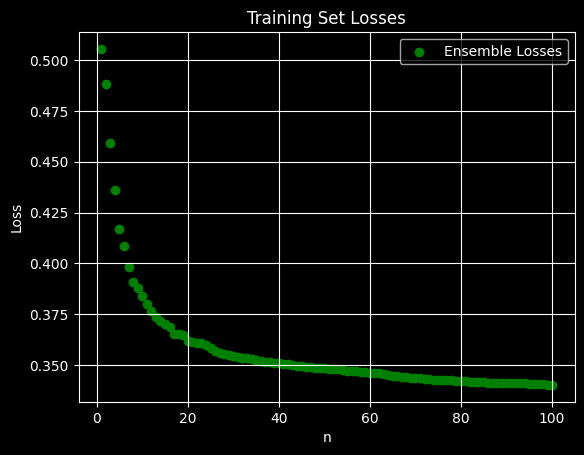

2026-03-04 15:57:06,922 - bayesian_trees.gradient_booster - INFO - Losses:
      n  ensemble_losses
0     1         0.499802
1     2         0.482824
2     3         0.454306
3     4         0.431408
4     5         0.412672
5     6         0.404011
6     7         0.394051
7     8         0.386431
8     9         0.383554
9    10         0.379618
10   11         0.375358
11   12         0.372327
12   13         0.370094
13   14         0.368254
14   15         0.366857
15   16         0.365475
16   17         0.362463
17   18         0.362146
18   19         0.361599
19   20         0.359203
20   21         0.358698
21   22         0.358320
22   23         0.357925
23   24         0.357548
24   25         0.356346
25   26         0.355292
26   27         0.354769
27   28         0.354073
28   29         0.353827
29   30         0.353444
30   31         0.353191
31   32         0.353082
32   33         0.352757
33   34         0.352858
34   35         0.352982
35   36         0.352986


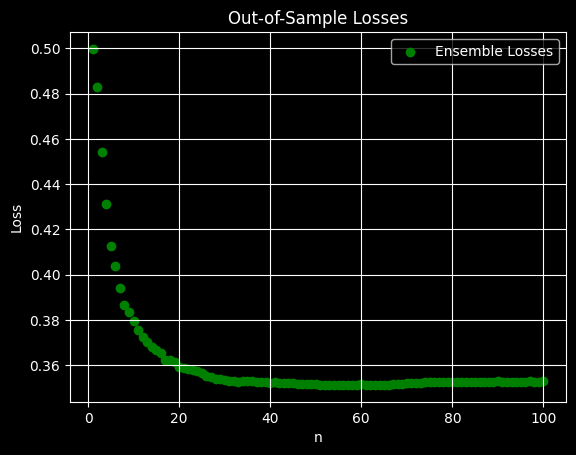

2026-03-04 15:57:07,060 - __main__ - INFO - Optimized number of trees: 63
2026-03-04 16:00:37,224 - bayesian_trees.gradient_booster - INFO - Losses:
      n  ensemble_losses
0     1         0.499959
1     2         0.483420
2     3         0.454739
3     4         0.432206
4     5         0.414337
5     6         0.405955
6     7         0.396573
7     8         0.389508
8     9         0.386731
9    10         0.383296
10   11         0.379416
11   12         0.376624
12   13         0.374482
13   14         0.372548
14   15         0.371579
15   16         0.370071
16   17         0.367309
17   18         0.367154
18   19         0.366719
19   20         0.364496
20   21         0.364199
21   22         0.363877
22   23         0.363606
23   24         0.363330
24   25         0.362248
25   26         0.361356
26   27         0.360889
27   28         0.360321
28   29         0.360188
29   30         0.359933
30   31         0.359741
31   32         0.359477
32   33         0.359302
3

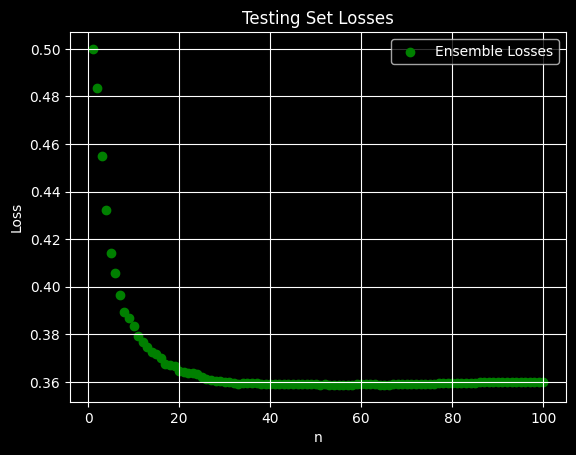

2026-03-04 16:02:52,636 - __main__ - INFO - Log-Loss: 0.3590
/tmp/ipykernel_115357/3833695989.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


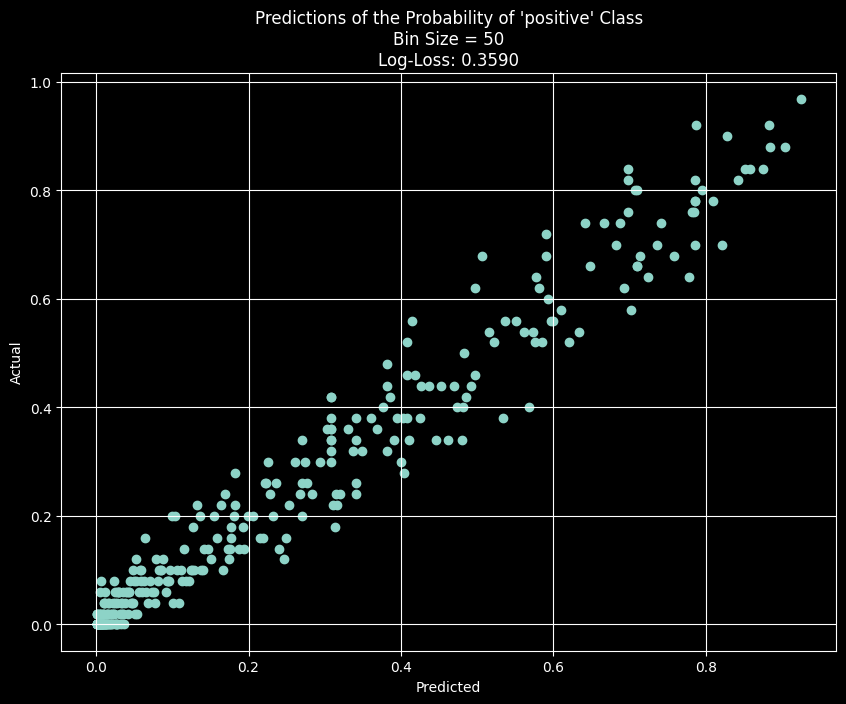

In [10]:
n_iter = 100
oos_frac = 0.2

tree_kwargs = {
    "split_method": "gain",
    "prior_method": "mle",
    "prior_alpha": [1.0, 1.0],
    "prior_cap": 100,
    "min_smooth_obs": 100,
    "min_prediction": 1e-6,
    "min_improvement": 1e-6,
    "max_level": 3,
    "predictors_to_ignore": 0.0,
    "write_log": False
}
gb_kwargs = {
    "n_iter": n_iter,
    "learning_rate": 0.1,
    "predictors_to_remove": 0.7,
    "sampling": {"frac": 0.7, "sync": False, "replace": True},
    "random_state": 1234
}

train_ind = np.random.choice(
    learn_data.shape[0],
    round((1.0 - oos_frac) * learn_data.shape[0]),
    replace=False
)

train_data = learn_data.loc[train_ind, :]
train_data.reset_index(drop=True, inplace=True)
oos_data = learn_data.loc[~learn_data.index.isin(train_ind), :]
oos_data.reset_index(drop=True, inplace=True)

gb = GradientBooster(**{**gb_kwargs, **tree_kwargs})
gb.fit(X=train_data[PREDICTORS], y=train_data[OUTCOMES_COLS])

gb.plot_losses(X=None)

oss_loss_data = gb.plot_losses(
    X=oos_data[PREDICTORS], y=oos_data[OUTCOMES_COLS], title="Out-of-Sample Losses"
)

opt_n_trees = oss_loss_data.loc[oss_loss_data["ensemble_losses"].idxmin(), "n"]
logger.info(f"Optimized number of trees: {opt_n_trees}")

gb.plot_losses(X=test_data[PREDICTORS], y=test_data[OUTCOMES_COLS])

predictions = gb.predict_proba(X=test_data[PREDICTORS], n_iter_to_use=opt_n_trees)
loss = get_log_loss(predictions, test_data[OUTCOMES_COLS])
logger.info(f"Log-Loss: {loss:.4f}")

f, plot_data = plot_performance_chart(
    predictions, test_data[OUTCOMES_COLS], "positive", 50, loss
)
f.show()

In [12]:
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier
)
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.tree import DecisionTreeClassifier

# Native Support for Categorical Features

2026-03-04 16:39:01,786 - __main__ - INFO - Log-Loss: 0.3581
/tmp/ipykernel_115357/404583453.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


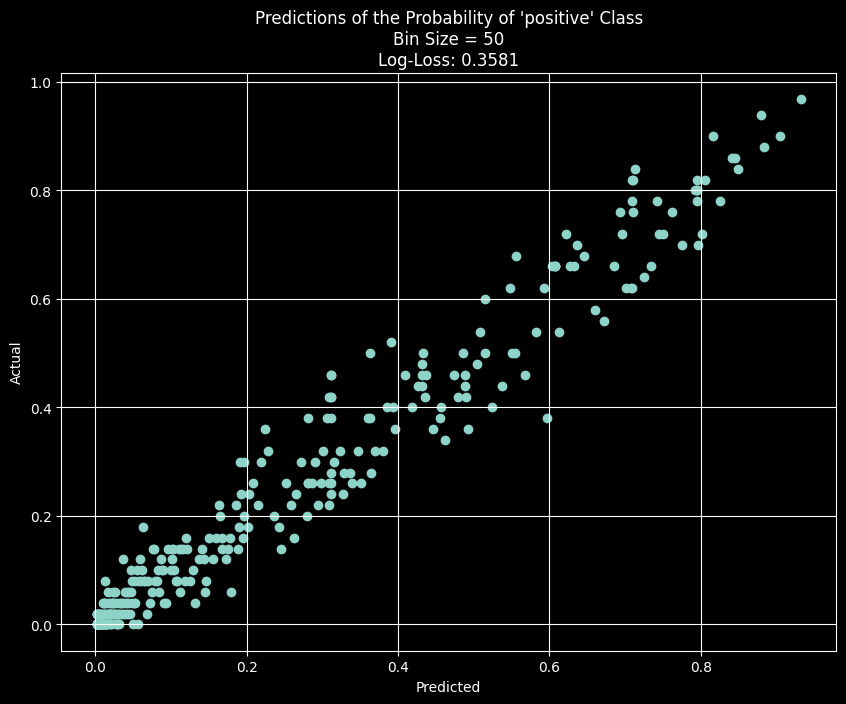

In [13]:
clf = HistGradientBoostingClassifier(categorical_features=PREDICTORS, random_state=1234)
clf.fit(learn_data[PREDICTORS], learn_data["positive"])

positive_estimates = np.clip(clf.predict_proba(test_data[PREDICTORS])[:, 1], 1e-6, 1 - 1e-6)
predictions = pd.DataFrame({"negative": 1 - positive_estimates, "positive": positive_estimates})
loss = get_log_loss(predictions, test_data[OUTCOMES_COLS])
logger.info(f"Log-Loss: {loss:.4f}")

f, plot_data = plot_performance_chart(
    predictions, test_data[OUTCOMES_COLS], "positive", 50, loss
)
f.show()

# Target Encoding of Categorical Features

In [14]:
raw_data_cat_cols = [
    c for c in raw_learn_data.columns if c not in OUTCOMES_COLS
]

encoder = TargetEncoder(target_type="binary", random_state=1234)
learn_data = pd.concat(
    [
        pd.DataFrame(
            encoder.fit_transform(raw_learn_data[raw_data_cat_cols], raw_learn_data["positive"]),
            columns=raw_data_cat_cols
        ),
        raw_learn_data[OUTCOMES_COLS]
    ],
    axis=1
)
test_data = pd.concat(
    [
        pd.DataFrame(
            encoder.transform(raw_test_data[raw_data_cat_cols]),
            columns=raw_data_cat_cols
        ),
        raw_test_data[OUTCOMES_COLS]
    ],
    axis=1
)
print(learn_data.head())

predictors = [c for c in learn_data.columns if c not in OUTCOMES_COLS]

   workclass  education  marital-status  occupation  relationship      race  \
0   0.271204   0.417814        0.042765    0.134619      0.099860  0.256771   
1   0.287912   0.410472        0.446977    0.481165      0.449287  0.255785   
2   0.218595   0.163314        0.102555    0.063784      0.104399  0.255824   
3   0.218439   0.052630        0.445253    0.072767      0.446061  0.130816   
4   0.218514   0.417814        0.450473    0.445997      0.477557  0.119330   

        sex  native-country  negative  positive  
0  0.306195        0.245611         1         0  
1  0.306368        0.245597         1         0  
2  0.305003        0.246244         1         0  
3  0.305484        0.245823         1         0  
4  0.108827        0.259997         1         0  


2026-03-04 16:41:21,574 - __main__ - INFO - Log-Loss: 0.3707
/tmp/ipykernel_115357/2926850708.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


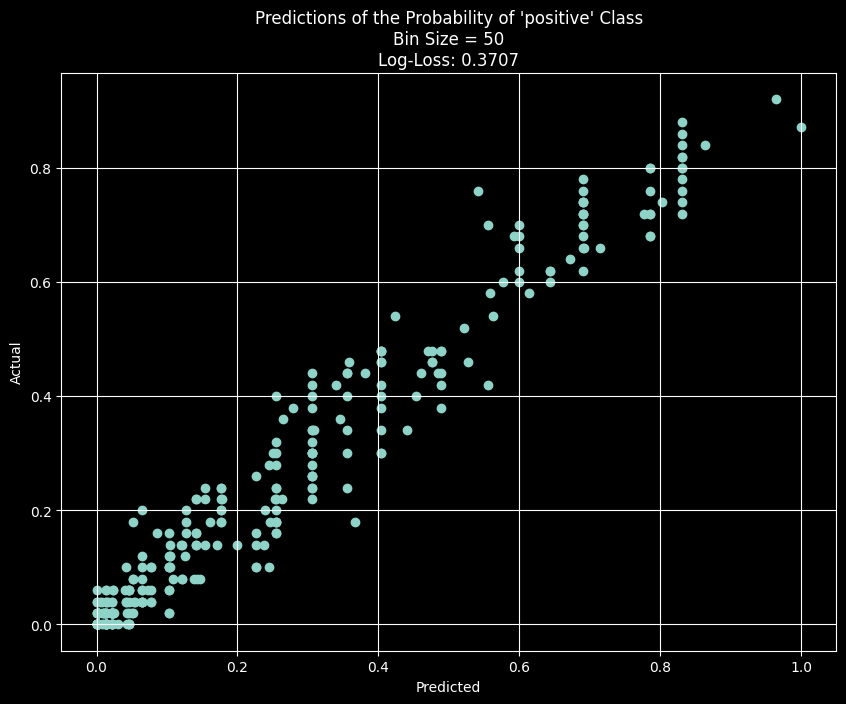

In [15]:
clf = DecisionTreeClassifier(max_depth=7, min_samples_leaf=20, criterion="log_loss", random_state=1234)
clf.fit(learn_data[predictors], learn_data[OUTCOMES_COLS])

positive_estimates = np.clip(clf.predict_proba(test_data[predictors])[1][:, 1], 1e-6, 1 - 1e-6)
predictions = pd.DataFrame({"negative": 1 - positive_estimates, "positive": positive_estimates})
loss = get_log_loss(predictions, test_data[OUTCOMES_COLS])
logger.info(f"Log-Loss: {loss:.4f}")

f, plot_data = plot_performance_chart(
    predictions, test_data[OUTCOMES_COLS], "positive", 50, loss
)
f.show()

2026-03-04 16:41:37,297 - __main__ - INFO - Log-Loss: 0.3605
/tmp/ipykernel_115357/1122608017.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


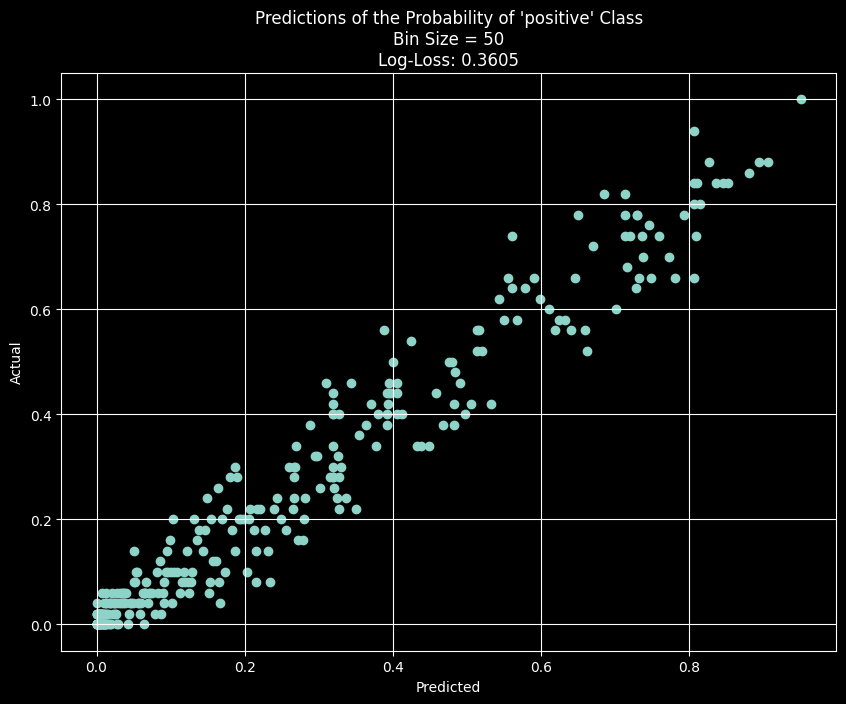

In [16]:
clf = RandomForestClassifier(max_depth=15, criterion="log_loss", random_state=1234)
clf.fit(learn_data[predictors], learn_data[OUTCOMES_COLS])

positive_estimates = np.clip(clf.predict_proba(test_data[predictors])[1][:, 1], 1e-6, 1 - 1e-6)
predictions = pd.DataFrame({"negative": 1 - positive_estimates, "positive": positive_estimates})
loss = get_log_loss(predictions, test_data[OUTCOMES_COLS])
logger.info(f"Log-Loss: {loss:.4f}")

f, plot_data = plot_performance_chart(
    predictions, test_data[OUTCOMES_COLS], "positive", 50, loss
)
f.show()

2026-03-04 16:43:22,072 - __main__ - INFO - Log-Loss: 0.3572
/tmp/ipykernel_115357/4221130433.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


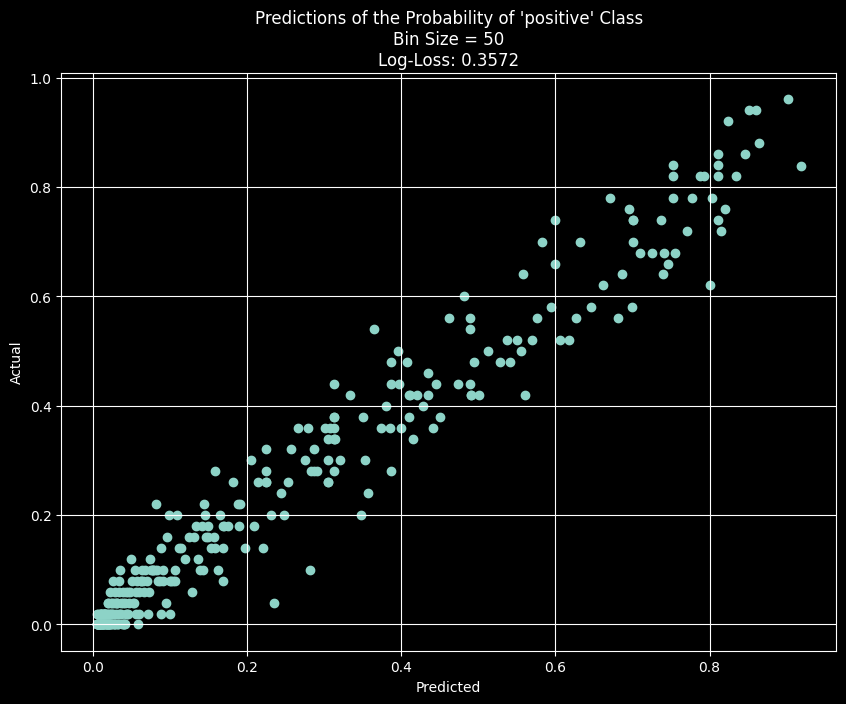

In [17]:
clf = GradientBoostingClassifier(random_state=1234)
clf.fit(learn_data[predictors], learn_data["positive"])

positive_estimates = np.clip(clf.predict_proba(test_data[predictors])[:, 1], 1e-6, 1 - 1e-6)
predictions = pd.DataFrame({"negative": 1 - positive_estimates, "positive": positive_estimates})
loss = get_log_loss(predictions, test_data[OUTCOMES_COLS])
logger.info(f"Log-Loss: {loss:.4f}")

f, plot_data = plot_performance_chart(
    predictions, test_data[OUTCOMES_COLS], "positive", 50, loss
)
f.show()

2026-03-04 16:43:42,182 - __main__ - INFO - Log-Loss: 0.3565
/tmp/ipykernel_115357/1532510343.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


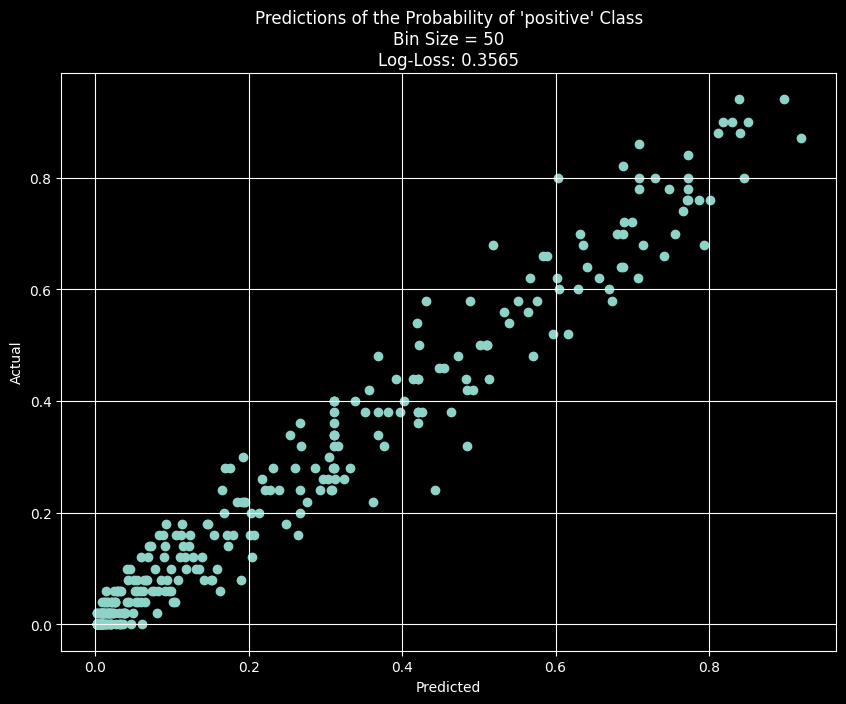

In [18]:
clf = HistGradientBoostingClassifier(categorical_features=None, random_state=1234)
clf.fit(learn_data[predictors], learn_data["positive"])

positive_estimates = np.clip(clf.predict_proba(test_data[predictors])[:, 1], 1e-6, 1 - 1e-6)
predictions = pd.DataFrame({"negative": 1 - positive_estimates, "positive": positive_estimates})
loss = get_log_loss(predictions, test_data[OUTCOMES_COLS])
logger.info(f"Log-Loss: {loss:.4f}")

f, plot_data = plot_performance_chart(
    predictions, test_data[OUTCOMES_COLS], "positive", 50, loss
)
f.show()

# One-Hot Encoding of Categorical Features

In [19]:
raw_data_cat_cols = [
    c for c in raw_learn_data.columns if c not in OUTCOMES_COLS
]

encoder = OneHotEncoder(handle_unknown="ignore")
learn_data = pd.concat(
    [
        pd.DataFrame(
            encoder.fit_transform(raw_learn_data[raw_data_cat_cols]).toarray(),
            columns=encoder.get_feature_names_out()
        ),
        raw_learn_data[OUTCOMES_COLS]
    ],
    axis=1
)
test_data = pd.concat(
    [
        pd.DataFrame(
            encoder.transform(raw_test_data[raw_data_cat_cols]).toarray(),
            columns=encoder.get_feature_names_out()
        ),
        raw_test_data[OUTCOMES_COLS]
    ],
    axis=1
)
print(learn_data.head())

predictors = [c for c in learn_data.columns if c not in OUTCOMES_COLS]

   workclass_Federal-gov  workclass_Local-gov  workclass_Never-worked  \
0                    0.0                  0.0                     0.0   
1                    0.0                  0.0                     0.0   
2                    0.0                  0.0                     0.0   
3                    0.0                  0.0                     0.0   
4                    0.0                  0.0                     0.0   

   workclass_Private  workclass_Self-emp-inc  workclass_Self-emp-not-inc  \
0                0.0                     0.0                         0.0   
1                0.0                     0.0                         1.0   
2                1.0                     0.0                         0.0   
3                1.0                     0.0                         0.0   
4                1.0                     0.0                         0.0   

   workclass_State-gov  workclass_Without-pay  workclass_nan  education_10th  \
0                  1.0  

2026-03-04 16:44:28,073 - __main__ - INFO - Log-Loss: 0.3773
/tmp/ipykernel_115357/2926850708.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


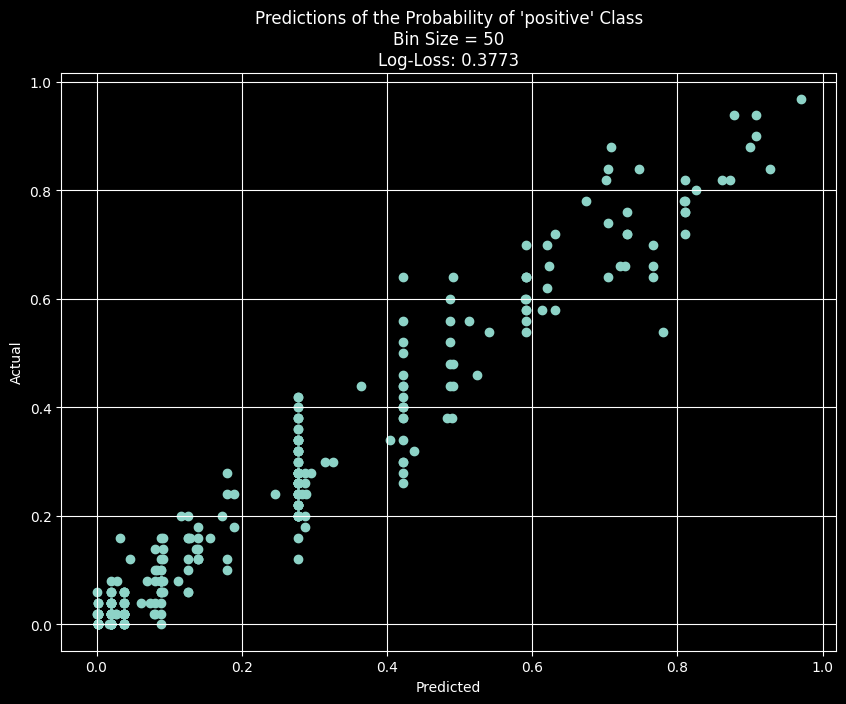

In [20]:
clf = DecisionTreeClassifier(max_depth=7, min_samples_leaf=20, criterion="log_loss", random_state=1234)
clf.fit(learn_data[predictors], learn_data[OUTCOMES_COLS])

positive_estimates = np.clip(clf.predict_proba(test_data[predictors])[1][:, 1], 1e-6, 1 - 1e-6)
predictions = pd.DataFrame({"negative": 1 - positive_estimates, "positive": positive_estimates})
loss = get_log_loss(predictions, test_data[OUTCOMES_COLS])
logger.info(f"Log-Loss: {loss:.4f}")

f, plot_data = plot_performance_chart(
    predictions, test_data[OUTCOMES_COLS], "positive", 50, loss
)
f.show()

2026-03-04 16:44:38,249 - __main__ - INFO - Log-Loss: 0.3631
/tmp/ipykernel_115357/1122608017.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


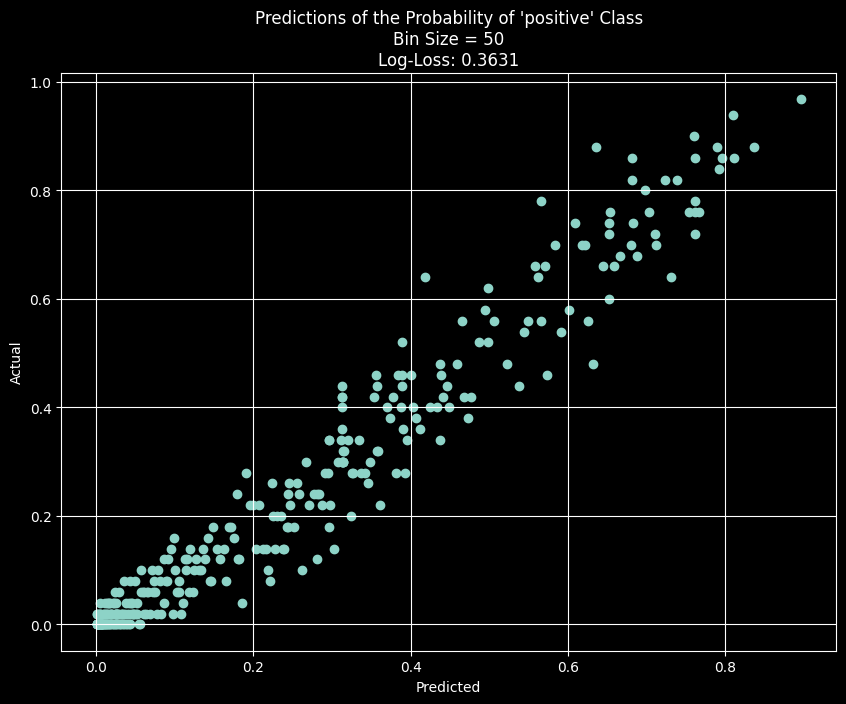

In [21]:
clf = RandomForestClassifier(max_depth=15, criterion="log_loss", random_state=1234)
clf.fit(learn_data[predictors], learn_data[OUTCOMES_COLS])

positive_estimates = np.clip(clf.predict_proba(test_data[predictors])[1][:, 1], 1e-6, 1 - 1e-6)
predictions = pd.DataFrame({"negative": 1 - positive_estimates, "positive": positive_estimates})
loss = get_log_loss(predictions, test_data[OUTCOMES_COLS])
logger.info(f"Log-Loss: {loss:.4f}")

f, plot_data = plot_performance_chart(
    predictions, test_data[OUTCOMES_COLS], "positive", 50, loss
)
f.show()

2026-03-04 16:44:59,772 - __main__ - INFO - Log-Loss: 0.3606
/tmp/ipykernel_115357/4221130433.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


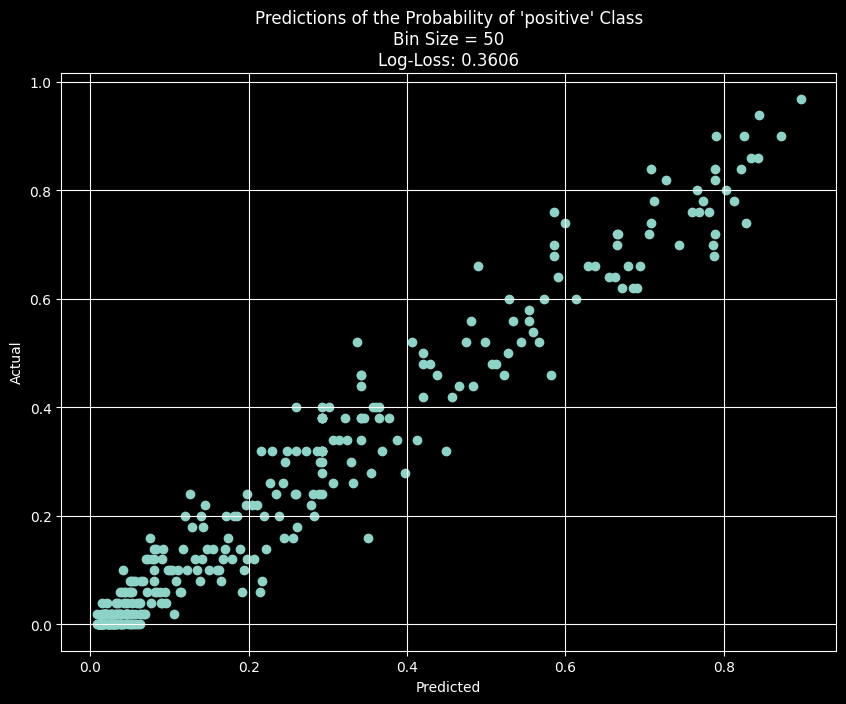

In [22]:
clf = GradientBoostingClassifier(random_state=1234)
clf.fit(learn_data[predictors], learn_data["positive"])

positive_estimates = np.clip(clf.predict_proba(test_data[predictors])[:, 1], 1e-6, 1 - 1e-6)
predictions = pd.DataFrame({"negative": 1 - positive_estimates, "positive": positive_estimates})
loss = get_log_loss(predictions, test_data[OUTCOMES_COLS])
logger.info(f"Log-Loss: {loss:.4f}")

f, plot_data = plot_performance_chart(
    predictions, test_data[OUTCOMES_COLS], "positive", 50, loss
)
f.show()

2026-03-04 16:45:10,202 - __main__ - INFO - Log-Loss: 0.3587
/tmp/ipykernel_115357/1532510343.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


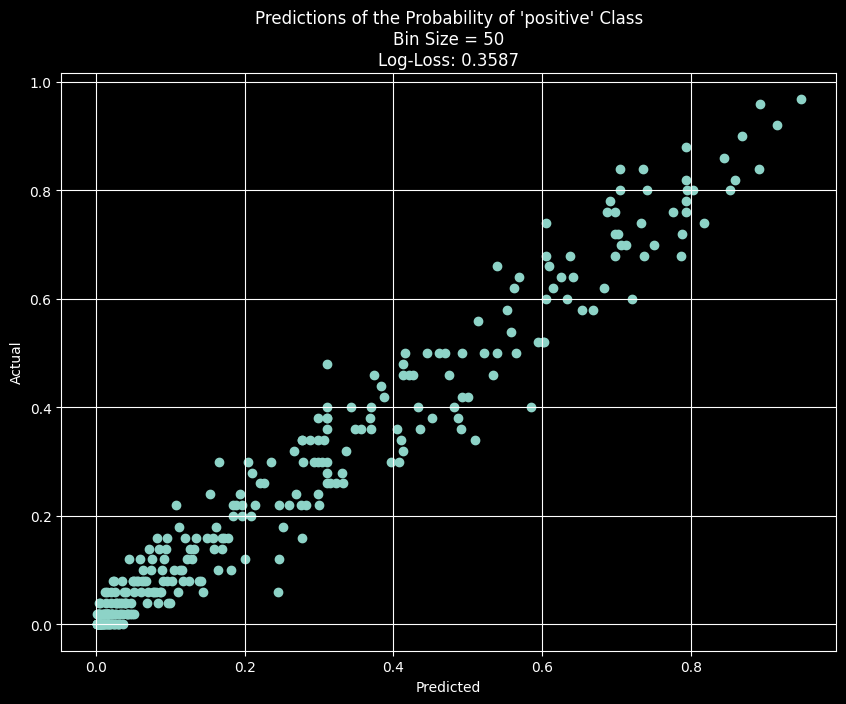

In [23]:
clf = HistGradientBoostingClassifier(categorical_features=None, random_state=1234)
clf.fit(learn_data[predictors], learn_data["positive"])

positive_estimates = np.clip(clf.predict_proba(test_data[predictors])[:, 1], 1e-6, 1 - 1e-6)
predictions = pd.DataFrame({"negative": 1 - positive_estimates, "positive": positive_estimates})
loss = get_log_loss(predictions, test_data[OUTCOMES_COLS])
logger.info(f"Log-Loss: {loss:.4f}")

f, plot_data = plot_performance_chart(
    predictions, test_data[OUTCOMES_COLS], "positive", 50, loss
)
f.show()